## Introduction

Commonsense reasoning is still a challenge for many language models and even humans: even strong baselines like BERT-large achieve only around 56% accuracy on CommonsenseQA, compared to 89% for humans (see [Talmor et al., 2019](https://aclanthology.org/N19-1421.pdf)). In this project, I explore how different transformer-based models handle commonsense reasoning, using the CommonsenseQA dataset. The task involves multiple-choice questions where the model must pick the most likely answer based on everyday knowledge.

To test the effects of pretraining and model scale, I compare:
- A **randomly initialized BERT model**, trained from scratch on the task
- A **pretrained BERT model** (`bert-base-uncased`), finetuned on the same data
- A **large language model** (FLAN-T5-XL), evaluated with zero-shot and few-shot prompting

Both BERT models used the same architecture and were trained with hyperparameter grid (learning rate, weight decay, scheduler). FLAN-T5 was only prompted, not fine-tuned. The task baseline is 20% accuracy, which represents random guessing.

In terms of results, the randomly initialized BERT reached around **19%** accuracy, pretrained BERT achieved **55.2%**, and FLAN-T5-XL performed best with **almost 89%** in the zero-shot setting. I also analyzed model behavior using confusion matrices, prefix-based accuracy, question length and disagreements between models.

**WandB Link:** [Project 2 Link](https://wandb.ai/flora-gashi-hochschule-luzern/commonsenseqa-project-2?nw=nwuserfloragashi)

## Setup

In [ ]:
!pip install -U wandb
!pip install -U datasets
!pip install -U scikit-learn
!pip install -U transformers
!pip install ipytest

In [2]:
import os
import re
import random
from collections import defaultdict
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
import ipytest
import wandb
from datasets import load_dataset
from transformers import (
    AutoTokenizer,
    BertConfig,
    BertForMultipleChoice,
    AutoModelForMultipleChoice,
    TrainingArguments,
    Trainer,
    TrainerCallback,
    EarlyStoppingCallback,
    DataCollatorForMultipleChoice,
    pipeline
)

### Data split

In [3]:
train = load_dataset("tau/commonsense_qa", split="train[:-1000]")
valid = load_dataset("tau/commonsense_qa", split="train[-1000:]")
test = load_dataset("tau/commonsense_qa", split="validation")

print(len(train), len(valid), len(test))

8741 1000 1221


### W&B Setup

In [7]:
os.environ["WANDB_NOTEBOOK_NAME"] = 'Project_2_Flora_Gashi.ipynb'

In [8]:
os.environ["WANDB_API_KEY"] = "" # removed my api key on purpose (privacy)

### Test Setup

In [4]:
ipytest.autoconfig()

## Preprocessing
- **Tokenization:**
I used Hugging Face's `AutoTokenizer` for `bert-base-uncased`, which includes WordPiece tokenization and lowercasing. Since the model expects tokenized input in this form, no additional preprocessing like stemming or lemmatization was applied.

- **Lowercasing / Punctuation / Stopwords:**
I did not remove stopwords or punctuation as BERT's tokenizer is pretrained to work on raw lowercased English text with punctuation. Manual removal would distort the input format the model was trained on. By removing stopwords questions would loose important information.

- **No stemming/lemmatizing:**
Stemming or lemmatization are not used, as BERT’s tokenizer handles word morphology through subword decomposition.

- **Handling unknown words:**
No filtering was needed. The tokenizer splits unknown words into known subwords, so even invented terms can be encoded.

- **Text Cleaning:**
I checked the dataset for unwanted characters like HTML tags or newlines using SQL queries directly in Hugging Face. The data is already clean and does not need extra processing. I executed following sql-queries for train and validation and got no matches:
```
SELECT * FROM (dataset)
WHERE question LIKE '%<%' OR question LIKE '%>%' OR question LIKE '%&%';
```
```
SELECT * FROM (dataset)
WHERE question ~ '[^a-zA-Z0-9\s\.,?!'']'
```
```
SELECT * FROM (dataset)
WHERE question LIKE '%\n%' OR question LIKE '%\t%'

```
```
SELECT question, COUNT(*) AS freq
FROM train
GROUP BY question
HAVING freq > 1
ORDER BY freq DESC
LIMIT 10;

```

- **Input format:**
Each question with its five answer choices is converted into five input pairs: `[CLS] question [SEP] answer_option [SEP]`. This format is used consistently across the random initialized and pretrained bert models.  


- **Label Format:**
The correct answer is given by a letter (A–E). I convert this to an index (0–4) using ord(label) - ord('A'), so it works with PyTorch's loss functions.

- **Truncation and padding:**
Truncation is handled by the tokenizer to fit within the model’s maximum input length. Padding is handled dynamically during batching.

- **Train/Validation/Test splits:**
From the original training split, we hold out the last 1,000 examples for validation. The provided validation split is used as the final test set.

- **Batching:**
I use a batch size of 64 for all BERT models, selected based on GPU memory constraints.

- **Vocabulary/Embeddings:** 
I rely entirely on the tokenizer and vocabulary of `bert-base-uncased`, without introducing custom tokens or embeddings to maintain compatibility with the pretrained model weights.


In [5]:
tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")

In [6]:
def clean_text(text):
    return re.sub(r"\s+", " ", text).strip()

def preprocess_dataset(examples):
    print("Ist batched?", isinstance(examples["question"], list))

    print("Beispielstruktur von examples['choices']:", examples["choices"][0])
    questions = [clean_text(q) for q in examples["question"]]

    choices_text = [
        [clean_text(choice) for choice in ex["text"]]
        for ex in examples["choices"]
    ]
    
    first_sentences = [[question] * 5 for question in questions]
    second_sentences = choices_text

    first_sentences = sum(first_sentences, [])
    second_sentences = sum(second_sentences, [])

    tokenized = tokenizer(first_sentences, second_sentences,
                          truncation=True,
                          padding=False)

    result = {k: [v[i:i + 5] for i in range(0, len(v), 5)] for k, v in tokenized.items()}
    result["labels"] = [ord(k) - ord("A") for k in examples["answerKey"]]
    return result

In [7]:
encoded_train = train.map(preprocess_dataset, batched=True)
encoded_valid = valid.map(preprocess_dataset, batched=True)
encoded_test = test.map(preprocess_dataset, batched=True)

- **Data Collator:**
To prepare batches for training and evaluation, I use Hugging Face’s `DataCollatorForMultipleChoice`.  
This is needed in this case because we use multiple (question, answer) pairs per sample as it simplifies the batching of nested inputs.

In [8]:
data_collator = DataCollatorForMultipleChoice(tokenizer=tokenizer)

### Correctness Test
To make sure that the preprocessing works correctly, I wrote a few small tests to make sure that each example is correctly formatted, includes five answers, uses the right tokens, stays within length limits, and matches expected label ranges.

In [9]:
encoded_train[1]

{'id': '61fe6e879ff18686d7552425a36344c8',
 'question': 'Sammy wanted to go to where the people were.  Where might he go?',
 'question_concept': 'people',
 'choices': {'label': ['A', 'B', 'C', 'D', 'E'],
  'text': ['race track',
   'populated areas',
   'the desert',
   'apartment',
   'roadblock']},
 'answerKey': 'B',
 'input_ids': [[101,
   14450,
   2359,
   2000,
   2175,
   2000,
   2073,
   1996,
   2111,
   2020,
   1012,
   2073,
   2453,
   2002,
   2175,
   1029,
   102,
   2679,
   2650,
   102],
  [101,
   14450,
   2359,
   2000,
   2175,
   2000,
   2073,
   1996,
   2111,
   2020,
   1012,
   2073,
   2453,
   2002,
   2175,
   1029,
   102,
   10357,
   2752,
   102],
  [101,
   14450,
   2359,
   2000,
   2175,
   2000,
   2073,
   1996,
   2111,
   2020,
   1012,
   2073,
   2453,
   2002,
   2175,
   1029,
   102,
   1996,
   5532,
   102],
  [101,
   14450,
   2359,
   2000,
   2175,
   2000,
   2073,
   1996,
   2111,
   2020,
   1012,
   2073,
   2453,
   2002,
  

In [10]:
def test_five_answer_options():
    for ex in encoded_train.select(range(10)):
        assert len(ex["input_ids"]) == 5, f"Error: Less than 5 answers at ID {ex['id']}"

def test_matching_input_lengths():
    ex = encoded_train[0]
    for i in range(5):
        assert len(ex["input_ids"][i]) == len(ex["attention_mask"][i]) == len(ex["token_type_ids"][i]), "Lengths do not match"

def test_label_range():
    label = encoded_train[0]["labels"]
    assert 0 <= label <= 4, "Label outside of expected range"

def test_decoded_contains_question_and_answer():
    idx = 0
    example = train[idx]
    question = example["question"]
    choices = example["choices"]["text"]
    input_pair = tokenizer(question, choices[0])
    decoded = tokenizer.decode(input_pair["input_ids"])

    assert question.lower()[:10] in decoded.lower(), "Question missing in decoded input"
    assert choices[0].lower()[:5] in decoded.lower(), "Answer option missing in decoded input"

def test_batch_structure():
    ex = encoded_train[0]
    assert isinstance(ex["input_ids"], list)
    assert all(isinstance(choice_input, list) for choice_input in ex["input_ids"])

def test_special_tokens_present():
    ex = encoded_train[0]
    for seq in ex["input_ids"]:
        assert 101 in seq, "[CLS] token missing"
        assert 102 in seq, "[SEP] token missing"

def test_max_sequence_length():
    max_len = 512
    for ex in encoded_train.select(range(10)):
        for seq in ex["input_ids"]:
            assert len(seq) <= max_len, "Input sequence exceeds model max length"

In [11]:
ipytest.run()

.......                                                                                      [100%]
========================================= warnings summary =========================================
../../opt/conda/lib/python3.12/site-packages/_pytest/config/__init__.py:1277
  /opt/conda/lib/python3.12/site-packages/_pytest/config/__init__.py:1277: PytestAssertRewriteWarning: Module already imported so cannot be rewritten: anyio
    self._mark_plugins_for_rewrite(hook)

-- Docs: https://docs.pytest.org/en/stable/how-to/capture-warnings.html
7 passed, 1 warning in 0.03s


<ExitCode.OK: 0>

## Model Architecture

For both the randomly initialized and pretrained models, I use the architecture of `bert-base-uncased` so I know that differences in performance are due to pretraining, not model size or capacity. I chose this model because we worked with it in class, and I’m familiar with its structure and behavior.

The classifier is based on Hugging Face’s `BertForMultipleChoice`, which uses the [CLS] token of each (question, answer) pair and predicts one of five options. I kept the architecture unchanged so no additional layers were added.

The pretrained model loads weights from the official `bert-base-uncased` checkpoint. For the randomly initialized version, I manually defined the full configuration: 12 transformer layers, 12 attention heads, hidden size of 768, and a dropout rate of 0.1. The model also includes layer normalization, as in the original BERT design.

The loss function is handled internally by the Hugging Face implementation (cross-entropy).

## Training Strategy

To isolate the effect of pretraining, I trained both models using the same architecture and explored different hyperparameter combinations using a grid search (3 learning rates × 2 weight decays × 2 scheduler types = 12 runs per model). I chose grid search because it makes sure that both models are trained under exactly the same controlled conditions, which makes the comparison fair.

The randomly initialized model was trained for up to 30 epochs, the pretrained one for 20. I expected the pretrained model to converge faster since it starts from useful weights, while the random model needs more time to learn basic representations. Early stopping was set with a patience of 12 (random) and 8 (pretrained), based on initial trials where shorter patience caused unstable results due to temporary plateaus.

I used the AdamW optimizer with weight decay, and relied on the built-in loss function (`BertForMultipleChoice` uses cross-entropy). Although I considered gradual unfreezing for the pretrained model, I decided against it to keep the comparison simple and fair.

All experiments were tracked with Weights & Biases, and the best model from each sweep was selected based on validation accuracy.

### Training Setup

In [10]:
sweep_config = {
    'method': 'grid',
    'metric': {
        'name': 'eval_loss',
        'goal': 'minimize'
    },
    'parameters': {
        'learning_rate': {
            'values': [1e-3, 1e-4, 1e-5]
        },
        'weight_decay': {
            'values': [0.01, 0.1]
        },
        'lr_scheduler_type': {
            'values': ['linear', 'cosine']
        }
    }
}

In [11]:
def compute_metrics(eval_pred):
    predictions, labels = eval_pred
    preds = predictions.argmax(axis=1)
    acc = accuracy_score(labels, preds)
    return {"accuracy": acc}

In [12]:
random.seed(42)
np.random.seed(42)
torch.manual_seed(42)

In [13]:
class EpochMetricsLogger(TrainerCallback):
    def __init__(self):
        self.train_losses = []

    def on_log(self, args, state, control, logs=None, **kwargs):
        if logs is not None and "loss" in logs and "epoch" in logs:
            self.train_losses.append(logs["loss"])

    def on_evaluate(self, args, state, control, metrics=None, trainer=None, **kwargs):
        if metrics is None or trainer is None:
            return

        epoch = int(state.epoch or state.global_step)

        train_loss = self.train_losses[-1] if self.train_losses else float('nan')
        
        try:
            predictions = trainer.predict(trainer.train_dataset)
            preds = predictions.predictions.argmax(axis=1)
            labels = predictions.label_ids
            train_acc = accuracy_score(labels, preds)
        except Exception as e:
            train_acc = float('nan')
            print(f"Could not compute train accuracy: {e}")
            
        val_acc = metrics.get("eval_accuracy", 0.0)
        val_loss = metrics.get("eval_loss", 0.0)

        print(
            f"Epoch {epoch}: "
            f"Train Loss = {train_loss:.4f} | "
            f"Train Acc = {train_acc:.4f} | "
            f"Val Acc = {val_acc:.4f} | "
            f"Val Loss = {val_loss:.4f}"
        )

        wandb.log({
            "epoch": epoch,
            "train_accuracy": train_acc,
            "train_loss": train_loss,
            "val_accuracy": val_acc,
            "val_loss": val_loss
        }, step=epoch)

        run = wandb.run
        if run is not None:
            run.summary["eval_accuracy"] = val_acc

(**ChatGPT:** I wrote an own training class first but had some problems while doing so, GPT suggested that I should use the Trainer from HugginFace. I never used it before so needed help for the implementation. GPT showed me how its usually used and I implemented it for my case)

In [14]:
def get_training_args(run_name, config, epochs=30):
    return TrainingArguments(
        output_dir=f"./results/{run_name}",
        eval_strategy="epoch",
        learning_rate=config.learning_rate,
        per_device_train_batch_size=64,
        per_device_eval_batch_size=64,
        num_train_epochs=epochs, 
        weight_decay=config.weight_decay,
        warmup_ratio=0.1,
        lr_scheduler_type=config.lr_scheduler_type,
        logging_dir=f"./logs/{run_name}",
        logging_steps=50,
        save_strategy="epoch",
        load_best_model_at_end=True,
        metric_for_best_model="eval_accuracy",
        greater_is_better=True,
        save_total_limit=10,
        report_to="wandb",
        run_name=run_name,
        fp16=True,
        seed=42
    )

### Model 1: Randomly initialized Transformer

In [28]:
def sweep_train_model_random():
    with wandb.init(tags=["random_init"]) as run:
        config = run.config

        run_name = f"bert-random-lr{config.learning_rate}-wd{config.weight_decay}-sched{config.lr_scheduler_type}"
        run.name = run_name

        model_config = BertConfig(
            hidden_size=768,
            intermediate_size=3072,
            num_hidden_layers=12,
            num_attention_heads=12,
            hidden_dropout_prob=0.1,
            attention_probs_dropout_prob=0.1,
            num_labels=5
        )

        model = BertForMultipleChoice(model_config)

        trainer = Trainer(
            model=model,
            args=get_training_args(run_name, config, epochs=30),
            train_dataset=encoded_train,
            eval_dataset=encoded_valid,
            tokenizer=tokenizer,
            data_collator=data_collator,
            compute_metrics=compute_metrics,
            callbacks=[EpochMetricsLogger(), EarlyStoppingCallback(early_stopping_patience=12)]
        )

        trainer.train()
        trainer.evaluate()

        trainer.save_model(f"./results/{run_name}/best_model")
        tokenizer.save_pretrained(f"./results/{run_name}/best_model")
        
        del model
        torch.cuda.empty_cache()

In [29]:
sweep_id = wandb.sweep(sweep_config, project="commonsenseqa-project-2")
wandb.agent(sweep_id, function=sweep_train_model_random)

Create sweep with ID: vohqrk5f
Sweep URL: https://wandb.ai/flora-gashi-hochschule-luzern/commonsenseqa-project-2/sweeps/vohqrk5f


wandb: Agent Starting Run: d5bpdvud with config:
wandb: 	learning_rate: 0.001
wandb: 	lr_scheduler_type: linear
wandb: 	weight_decay: 0.01
wandb: Currently logged in as: flora-gashi (flora-gashi-hochschule-luzern) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


/tmp/ipykernel_2665/1017395693.py:20: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(
wandb: WARNING Config item 'learning_rate' was locked by 'sweep' (ignored update).
wandb: WARNING Config item 'weight_decay' was locked by 'sweep' (ignored update).
wandb: WARNING Config item 'lr_scheduler_type' was locked by 'sweep' (ignored update).
You're using a BertTokenizerFast tokenizer. Please note that with a fast tokenizer, using the `__call__` method is faster than using a method to encode the text followed by a call to the `pad` method to get a padded encoding.


Epoch,Training Loss,Validation Loss,Accuracy
1,1.615000,1.609375,0.196000
2,1.619800,1.609375,0.200000
3,1.618200,1.609375,0.200000
4,1.616800,1.609375,0.193000
5,1.616300,1.609375,0.195000
6,1.618100,1.609375,0.200000
7,1.619800,1.609375,0.200000
8,1.619500,1.609375,0.200000
9,1.617200,1.609375,0.200000
10,1.613900,1.609375,0.200000


eval/accuracy,▄██▁▃██████████
eval/loss,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
eval/runtime,▂▁▃▃▃▃▃▂▄▂▃▂▁█▄
eval/samples_per_second,▇█▆▆▆▆▆▇▅▇▆▇█▁▅
eval/steps_per_second,▇█▆▆▆▆▆▇▅▇▆▇▇▁▅
train/epoch,▁▁▁▁▂▂▂▂▂▂▃▃▃▃▃▄▄▄▄▄▅▅▅▅▅▆▆▆▆▆▇▇▇▇▇█████
train/global_step,▁▁▁▁▂▂▂▂▂▃▃▃▃▄▄▄▄▄▅▅▅▅▅▅▆▆▆▆▆▆▇▇▇▇▇█████
train/grad_norm,▃▁▁▂▅▄▇▇▅▇▆▇▅▄▆▇▆▇▆▅▇▅▅▇▃▆▆▆▃▃▆▆▇▆▅▆█▅
train/learning_rate,▁▂▃▄▅▆▇██████▇▇▇▇▇▇▇▇▇▆▆▆▆▆▆▆▆▆▅▅▅▅▅▅▅
train/loss,▅▅▇██▅▆▇▅▆▇▇▅▄▆▇▇▆█▅█▄▆▆▅▁▄▄▅▆█▄▄▄▂▅▅▄
eval/accuracy,0.2


...

wandb: Agent Starting Run: uedxkms6 with config:
wandb: 	learning_rate: 1e-05
wandb: 	lr_scheduler_type: cosine
wandb: 	weight_decay: 0.1


/tmp/ipykernel_2665/1017395693.py:20: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(
wandb: WARNING Config item 'learning_rate' was locked by 'sweep' (ignored update).
wandb: WARNING Config item 'weight_decay' was locked by 'sweep' (ignored update).
wandb: WARNING Config item 'lr_scheduler_type' was locked by 'sweep' (ignored update).


Epoch,Training Loss,Validation Loss,Accuracy
1,1.614100,1.607909,0.188000
2,1.617900,1.607779,0.190000
3,1.614400,1.606412,0.193000
4,1.612100,1.605149,0.192000
5,1.609600,1.604621,0.194000
6,1.595200,1.615156,0.189000
7,1.574800,1.635177,0.184000
8,1.537100,1.728514,0.163000
9,1.514100,1.889748,0.155000
10,1.474800,1.790188,0.164000


eval/accuracy,▇████▇▇▅▄▅▁▁▃▄▃▂▃█
eval/loss,▁▁▁▁▁▁▁▂▃▂▃▅▅▆▆▇█▁
eval/runtime,▁▁▂▁▂▁▁▁▂▁▂▁▁█▂▁▂▁
eval/samples_per_second,██▇▇▇███▇█▇██▁▇█▇█
eval/steps_per_second,██▇▇▇███▇█▇██▁▇█▇█
train/epoch,▁▁▁▁▂▂▂▂▂▂▃▃▃▃▃▄▄▄▄▄▅▅▅▅▅▅▆▆▆▆▇▇▇▇▇▇████
train/global_step,▁▁▁▁▂▂▂▂▂▃▃▃▃▃▃▄▄▄▄▄▄▅▅▅▅▅▆▆▆▆▇▇▇▇▇▇████
train/grad_norm,▂▂▂▂▁▁▁▁▁▁▁▁▁▂▂▂▂▃▃▃▄▄▄▄▅▅▄▅▆▅▅▇▅▆▅██▇▇█
train/learning_rate,▁▂▃▄▅▆▇███████████▇▇▇▇▇▇▇▇▆▆▆▆▆▆▅▅▅▅▅▄▄▄
train/loss,██████████████▇▇▇▇▇▇▆▆▅▆▅▅▅▅▄▄▄▄▄▃▃▃▂▂▂▁
eval/accuracy,0.194


wandb: Sweep Agent: Waiting for job.
wandb: Sweep Agent: Exiting.


### Model 2: Pretrained Transformer

In [25]:
def sweep_train_model_pretrained():
    with wandb.init(tags=["pretrained"]) as run:
        config = run.config
        run_name = f"bert-pretrained-lr{config.learning_rate}-wd{config.weight_decay}-sched{config.lr_scheduler_type}"
        run.name = run_name

        model = AutoModelForMultipleChoice.from_pretrained("bert-base-uncased")

        trainer = Trainer(
            model=model,
            args=get_training_args(run_name, config, epochs=20),
            train_dataset=encoded_train,
            eval_dataset=encoded_valid,
            tokenizer=tokenizer,
            data_collator=data_collator,
            compute_metrics=compute_metrics,
            callbacks=[EpochMetricsLogger(), EarlyStoppingCallback(early_stopping_patience=8)]
        )

        trainer.train()
        trainer.evaluate()

        trainer.save_model(f"./results/{run_name}/best_model")
        tokenizer.save_pretrained(f"./results/{run_name}/best_model")

        del model
        torch.cuda.empty_cache()

In [26]:
sweep_id_2 = wandb.sweep(sweep_config, project="commonsenseqa-project-2")
wandb.agent(sweep_id_2, function=sweep_train_model_pretrained)

Create sweep with ID: sdlmnvc4
Sweep URL: https://wandb.ai/flora-gashi-hochschule-luzern/commonsenseqa-project-2/sweeps/sdlmnvc4


wandb: Agent Starting Run: muvgmbct with config:
wandb: 	learning_rate: 0.001
wandb: 	lr_scheduler_type: linear
wandb: 	weight_decay: 0.01
wandb: Currently logged in as: flora-gashi (flora-gashi-hochschule-luzern) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Some weights of BertForMultipleChoice were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/tmp/ipykernel_4679/1786962206.py:9: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(
wandb: WARNING Config item 'learning_rate' was locked by 'sweep' (ignored update).
wandb: WARNING Config item 'weight_decay' was locked by 'sweep' (ignored update).
wandb: WARNING Config item 'lr_scheduler_type' was locked by 'sweep' (ignored update).
You're using a BertTokenizerFast tokenizer. Please note that with a fast tokenizer, using the `__call__` method is faster than using a method to encode the text followed by a call to the `pad` method to get a padded encoding.


...

wandb: Sweep Agent: Waiting for job.
wandb: Job received.
wandb: Agent Starting Run: d9mr2cul with config:
wandb: 	learning_rate: 1e-05
wandb: 	lr_scheduler_type: cosine
wandb: 	weight_decay: 0.1


Some weights of BertForMultipleChoice were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/tmp/ipykernel_4679/1786962206.py:9: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(
wandb: WARNING Config item 'learning_rate' was locked by 'sweep' (ignored update).
wandb: WARNING Config item 'weight_decay' was locked by 'sweep' (ignored update).
wandb: WARNING Config item 'lr_scheduler_type' was locked by 'sweep' (ignored update).


Epoch,Training Loss,Validation Loss,Accuracy
1,1.498900,1.363296,0.454000
2,1.335900,1.234218,0.516000
3,1.182400,1.154629,0.536000
4,1.014600,1.124196,0.538000
5,0.902300,1.138756,0.553000
6,0.767500,1.195722,0.558000
7,0.647100,1.235812,0.553000
8,0.563400,1.321400,0.535000
9,0.494900,1.360231,0.548000
10,0.408900,1.447871,0.545000


eval/accuracy,▁▅▇▇███▆▇▇▇▇▇▇█
eval/loss,▄▃▁▁▁▂▃▄▄▆▆▆██▂
eval/runtime,▁▂▂▂▁▂▇▁▂▂█▂▂▂▁
eval/samples_per_second,█▇▇▇▇▇▂█▇▇▁▇▇▇█
eval/steps_per_second,█▇▇▇▇▇▂█▇▇▁▇▇▇█
train/epoch,▁▁▁▁▂▂▂▂▂▂▃▃▃▃▃▄▄▄▄▄▅▅▅▅▅▆▆▆▆▆▆▇▇▇▇█████
train/global_step,▁▁▁▂▂▂▂▂▂▃▃▃▃▃▄▄▄▄▄▅▅▅▅▅▅▆▆▆▆▆▇▇▇▇▇█████
train/grad_norm,▁▂▃▃▃▄▄▄▄▄▄▃▄▅▅▅▆▆▄▅▄▄█▇▅▆▇▄▃▅▅▄▅▄▆▄▆█
train/learning_rate,▁▃▄▆▇████████▇▇▇▇▇▇▆▆▆▆▅▅▅▅▄▄▄▄▃▃▃▂▂▂▂
train/loss,███▇▇▇▆▆▆▅▅▅▅▄▄▄▃▃▃▃▃▃▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁
eval/accuracy,0.558


wandb: Sweep Agent: Waiting for job.
wandb: Sweep Agent: Exiting.


## Model 3: LLM (flan-t5-xl)
To compare against the fine-tuned transformer models, I used flan-t5-xl as a large language model with 2.85 billion parameters. I chose this model because it is openly available, instruction-tuned on a wide range of tasks (1.8K+), and supports reasoning through prompt-based interfaces. Its size allows it to handle complex multiple-choice questions without task-specific fine-tuning. ([see flan-t5-xl on Hugging Face](https://huggingface.co/google/flan-t5-xxl))

I used two prompt engineering strategies:

- **Zero-shot**: I simply asked the model the question and listed the five answer options
- **Few-shot**: I added three examples before the actual question. Each example was formatted similarly and included the correct answer letter (A–E) to guide the model.

The input format for each example was:
```
Question: ...
A. ...
B. ...
C. ...
D. ...
E. ...
Answer:
```

In few-shot prompting, the three examples were prepended to the prompt, followed by the test question in the same format. The model’s output was parsed using a regular expression to extract the predicted letter (A–E).  

In [ ]:
llm = pipeline("text2text-generation", model="google/flan-t5-xl", device=0)

In [16]:
question = "What is the capital of France?"
choices = ["Berlin", "Madrid", "Paris", "Rome"]

prompt = f"Question: {question}\n" + "\n".join([f"{chr(65+i)}. {c}" for i, c in enumerate(choices)]) + "\nAnswer:"

output = llm(prompt, max_new_tokens=10)[0]["generated_text"]
print("Model output:", output)

Model output: C.


In [17]:
def format_prompt_with_optional_fewshot(question, choices, few_shot_examples=None):
    prompt_parts = []

    if few_shot_examples:
        for ex in few_shot_examples:
            lettered = [f"{chr(65+i)}. {choice}" for i, choice in enumerate(ex["choices"])]
            prompt_parts.append(f"Question: {ex['question']}\n" + "\n".join(lettered) + f"\nAnswer: {ex['answerKey']}\n")

    lettered_q = [f"{chr(65+i)}. {choice}" for i, choice in enumerate(choices)]
    prompt_parts.append(f"Question: {question}\n" + "\n".join(lettered_q) + "\nAnswer:")

    return "\n".join(prompt_parts)

In [18]:
def evaluate_llm_accuracy(model_pipeline, dataset, model_name, few_shot_examples=None, max_examples=None):
    correct = 0
    total = 0
    wrong_examples = []

    for i, example in enumerate(dataset):
        if max_examples and i >= max_examples:
            break

        question = example["question"]
        choices = example["choices"]["text"]
        correct_answer = example["answerKey"]

        prompt = format_prompt_with_optional_fewshot(question, choices, few_shot_examples)
        output = model_pipeline(prompt, max_new_tokens=10, do_sample=False)[0]["generated_text"]

        match = re.search(r"\b([A-E])\b", output)
        prediction = match.group(1) if match else "None"

        is_correct = prediction == correct_answer
        correct += int(is_correct)
        total += 1

        if not is_correct:
            wrong_examples.append({
                "question": question,
                "choices": choices,
                "correct": correct_answer,
                "predicted": prediction,
                "output": output.strip()
            })

    accuracy = correct / total if total else 0.0
    print(f"\nAccuracy for {model_name}: {accuracy:.3f} ({correct}/{total})")
    return accuracy, wrong_examples

### Correctness Tests
(**ChatGPT** was used for etxra test ideas. I had defined two tests (test_prompt_contains_5_choices & test_output_letter_match), GPt suggested the other three tests which I then implemented myself)

In [17]:
example = {
    "question": "What is the capital of France?",
    "choices": ["Paris", "Berlin", "London", "Rome", "Madrid"],
    "answerKey": "A"
}

fewshot_examples = [example] * 3 

def test_prompt_contains_5_choices():
    prompt = format_prompt_with_optional_fewshot(example["question"], example["choices"])
    assert prompt.count("\nA.") == 1
    assert prompt.count("\nB.") == 1
    assert prompt.count("\nC.") == 1
    assert prompt.count("\nD.") == 1
    assert prompt.count("\nE.") == 1

def test_prompt_ends_with_answer_line():
    prompt = format_prompt_with_optional_fewshot(example["question"], example["choices"])
    assert prompt.strip().endswith("Answer:")

def test_fewshot_has_three_examples():
    prompt = format_prompt_with_optional_fewshot(example["question"], example["choices"], few_shot_examples=fewshot_examples)
    assert prompt.count("Question:") == 4

def test_output_letter_match():
    output = "Answer: A"
    match = re.search(r"\b([A-E])\b", output)
    assert match is not None
    assert match.group(1) in "ABCDE"

def test_prompt_contains_question_text():
    prompt = format_prompt_with_optional_fewshot(example["question"], example["choices"])
    assert "capital of France" in prompt
    
ipytest.run()

............                                                                                 [100%]
========================================= warnings summary =========================================
../../opt/conda/lib/python3.12/site-packages/_pytest/config/__init__.py:1277
  /opt/conda/lib/python3.12/site-packages/_pytest/config/__init__.py:1277: PytestAssertRewriteWarning: Module already imported so cannot be rewritten: anyio
    self._mark_plugins_for_rewrite(hook)

-- Docs: https://docs.pytest.org/en/stable/how-to/capture-warnings.html
12 passed, 1 warning in 0.03s


<ExitCode.OK: 0>

## Evaluation

To compare the models fairly, I evaluated all three on the same test set (`encoded_test`) using accuracy as the main metric.

- For the two BERT models, I selected the best run per sweep based on validation accuracy using the W&B API. I then loaded the corresponding model checkpoint from the local `./results` directory for evaluation
- I used the Hugging Face `Trainer` to run final evaluation on the test set
  
For the LLM, I called the evaluation function from earlier. Only the few-shot version was used for comparison, as it performed better than the zero-shot setup.

Summary of the results were:
| Model           | Validation Accuracy | Test Accuracy |
|----------------|---------------------|---------------|
| Baseline     | 20.0 %                | 20.0 %          |
| Random BERT     | 22.1 %                | 17.4 %          |
| Pretrained BERT | 57.2 %                | 55.2 %          |
| FLAN-T5-XL (zero-shot) | –            | 88.7 %          |
| FLAN-T5-XL (few-shot) | –            | 89.2 %          |

### Bert: Randomly Initialized & Pretrained Model

In [25]:
api = wandb.Api()
project_name = "flora-gashi-hochschule-luzern/commonsenseqa-project-2"

runs = api.runs(project_name)

best_random = max(
    (r for r in runs if "random_init" in r.tags),
    key=lambda r: r.summary.get("eval_accuracy", 0)
)

best_pretrained = max(
    (r for r in runs if "pretrained" in r.tags),
    key=lambda r: r.summary.get("eval_accuracy", 0)
)

print("Best Random Model:", best_random.name)
print("Best Pretrained Model:", best_pretrained.name)

Best Random Model: bert-random-lr0.0001-wd0.01-schedcosine
Best Pretrained Model: bert-pretrained-lr0.001-wd0.01-schedlinear


In [19]:
def evaluate_model_checkpoints(run_name, model_class, tokenizer_class, dataset):
    model_path = f"./results/{run_name}/best_model"
    model = model_class.from_pretrained(model_path)
    tokenizer = tokenizer_class.from_pretrained(model_path)
    data_collator = DataCollatorForMultipleChoice(tokenizer=tokenizer)

    args = TrainingArguments(
        output_dir="./eval",
        per_device_eval_batch_size=64,
        seed=42,
        report_to="none",
        logging_strategy="no"
    )

    trainer = Trainer(
        model=model,
        tokenizer=tokenizer,
        args=args,
        data_collator=data_collator,
        compute_metrics=compute_metrics
    )

    results = trainer.evaluate(eval_dataset=dataset)

    print(f"\nEvaluation Results for {run_name}:")
    for k, v in results.items():
        print(f"{k}: {v:.4f}")

    return results["eval_accuracy"]

In [20]:
evaluate_model_checkpoints(
    run_name="bert-random-lr0.0001-wd0.01-schedcosine",
    model_class=BertForMultipleChoice,
    tokenizer_class=AutoTokenizer,
    dataset=encoded_test
)

/tmp/ipykernel_12298/3756457140.py:15: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(
You're using a BertTokenizerFast tokenizer. Please note that with a fast tokenizer, using the `__call__` method is faster than using a method to encode the text followed by a call to the `pad` method to get a padded encoding.



Evaluation Results for bert-random-lr0.0001-wd0.01-schedcosine:
eval_loss: 1.6094
eval_model_preparation_time: 0.0023
eval_accuracy: 0.1736
eval_runtime: 22.6059
eval_samples_per_second: 54.0120
eval_steps_per_second: 0.8850


0.17362817362817362

In [21]:
evaluate_model_checkpoints(
    run_name="bert-pretrained-lr0.0001-wd0.01-schedlinear",
    model_class=AutoModelForMultipleChoice,
    tokenizer_class=AutoTokenizer,
    dataset=encoded_test
)

/tmp/ipykernel_12298/3756457140.py:15: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(
You're using a BertTokenizerFast tokenizer. Please note that with a fast tokenizer, using the `__call__` method is faster than using a method to encode the text followed by a call to the `pad` method to get a padded encoding.



Evaluation Results for bert-pretrained-lr0.0001-wd0.01-schedlinear:
eval_loss: 1.1311
eval_model_preparation_time: 0.0024
eval_accuracy: 0.5520
eval_runtime: 22.4485
eval_samples_per_second: 54.3910
eval_steps_per_second: 0.8910


0.552006552006552

### LLM: ZeroShot vs. FewShot

In [26]:
# zero-shot
acc_zero, wrong_zero = evaluate_llm_accuracy(llm, test, model_name="FLAN-T5-ZeroShot")

# few-shot
fewshot_examples = [train[i] for i in range(3)]
acc_few, wrong_few = evaluate_llm_accuracy(llm, test, model_name="FLAN-T5-FewShot", few_shot_examples=fewshot_examples)



Accuracy for FLAN-T5-ZeroShot: 0.887 (1083/1221)

Accuracy for FLAN-T5-FewShot: 0.892 (1089/1221)


### Error Analysis
To better understand each model's performance, I perfomed the following error analysis:

- **Confusion Matrix**: Side-by-side confusion matrices for the two BERT models
- **Wrong Predictions**: Printed 10 incorrectly predicted examples per model and compared predictions directly
- **Disagreement Analysis**: Identified cases where the two BERT models disagreed and at least one was wrong
- **Prefix Based Accuracy**: Calculated accuracy grouped by the first word (prefix) of each question and visualized the top 5 most common prefixes
- **Question Length Analysis**: grouped questions into length bins and computed accuracy per bin
- **Question Length Analysis**: Visualized how often each wrong option (A–E) was predicted per model
- **LLM Error Inspection**: Printed 15 wrong predictions with outputs
- **LLM Wins over Both**: Defined a function to find questions that both BERT models answered incorrectly but the LLM got right


In [24]:
def get_predictions_from_model(model_path, encoded_dataset, original_dataset):
    model = BertForMultipleChoice.from_pretrained(model_path)

    trainer = Trainer(
        model=model,
        tokenizer=tokenizer,
        data_collator=data_collator,
        compute_metrics=lambda x: {},
        args=TrainingArguments(
            output_dir="./temp",
            per_device_eval_batch_size=64,
            seed=42,
            report_to="none",
            logging_strategy="no"
        )
    )

    predictions = trainer.predict(encoded_dataset)
    preds = predictions.predictions.argmax(-1)
    labels = predictions.label_ids

    return {
        "preds": preds,
        "labels": labels,
        "samples": original_dataset
    }

In [ ]:
# get overall results from random & pretrained transfomer models
results_model1 = get_predictions_from_model(
    model_path="./results/bert-random-lr0.0001-wd0.01-schedcosine/best_model",
    encoded_dataset=encoded_test,
    original_dataset=test
)

results_model2 = get_predictions_from_model(
    model_path="./results/bert-pretrained-lr0.0001-wd0.01-schedlinear/best_model",
    encoded_dataset=encoded_test,
    original_dataset=test
)

In [26]:
# get wrongly predicted examples from random & pretrained transfomer models
wrong_model1 = []
wrong_model2 = []

for i in range(len(results_model1["labels"])):
    if results_model1["preds"][i] != results_model1["labels"][i]:
        wrong_model1.append(results_model1["samples"][i])
    if results_model2["preds"][i] != results_model2["labels"][i]:
        wrong_model2.append(results_model2["samples"][i])

(**ChatGPT** was used to print the plots side by side)

In [22]:
def plot_confusion_matrices_side_by_side(preds1, labels1, preds2, labels2, labels=["A", "B", "C", "D", "E"]):
    from sklearn.metrics import confusion_matrix
    import matplotlib.pyplot as plt

    cm1 = confusion_matrix(labels1, preds1)
    cm2 = confusion_matrix(labels2, preds2)

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    
    disp1 = ConfusionMatrixDisplay(confusion_matrix=cm1, display_labels=labels)
    disp1.plot(ax=axes[0], cmap="Blues", values_format='d')
    axes[0].set_title("Confusion Matrix – Model 1: Random")

    disp2 = ConfusionMatrixDisplay(confusion_matrix=cm2, display_labels=labels)
    disp2.plot(ax=axes[1], cmap="Blues", values_format='d')
    axes[1].set_title("Confusion Matrix – Model 2: Pretrained")

    plt.tight_layout()
    plt.show()

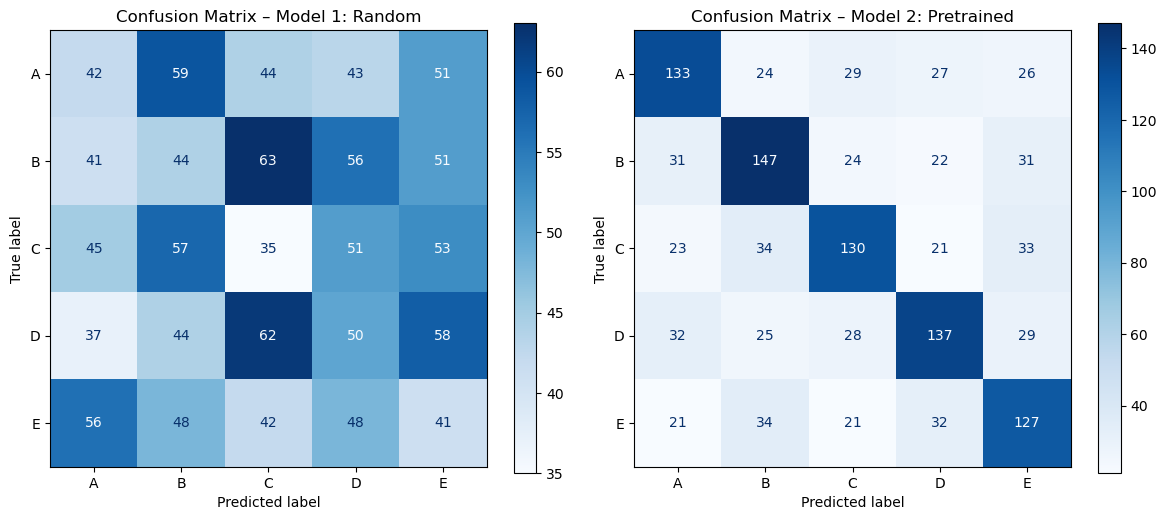

In [23]:
plot_confusion_matrices_side_by_side(
    results_model1["preds"],
    results_model1["labels"],
    results_model2["preds"],
    results_model2["labels"]
)

(**ChatGPT** was used for the output format for the examples, asked to give me a nice and structured output)

In [24]:
def print_wrong_examples(results, model_name, n=10):
    preds = results["preds"]
    labels = results["labels"]
    samples = results["samples"]

    print(f"\n{model_name} – {n} Incorrect Predictions:\n")
    count = 0
    for i in range(len(preds)):
        if preds[i] != labels[i]:
            ex = samples[i]
            print(f"Question: {ex['question']}")
            for j, option in enumerate(ex["choices"]["text"]):
                prefix = "→" if j == preds[i] else ("✓" if j == labels[i] else " ")
                print(f"{prefix} {chr(65 + j)}. {option}")
            print("---")
            count += 1
            if count >= n:
                break

In [25]:
print_wrong_examples(results_model1, "Model 1 (Random Init)")
print_wrong_examples(results_model2, "Model 2 (Pretrained)")


Model 1 (Random Init) – 10 Incorrect Predictions:

Question: Where would you find magazines along side many other printed works?
  A. doctor
✓ B. bookstore
  C. market
→ D. train station
  E. mortuary
---
Question: Where are  you likely to find a hamburger?
✓ A. fast food restaurant
→ B. pizza
  C. ground up dead cows
  D. mouth
  E. cow carcus
---
Question: James was looking for a good place to buy farmland.  Where might he look?
✓ A. midwest
→ B. countryside
  C. estate
  D. farming areas
  E. illinois
---
Question: What island country is ferret popular?
  A. own home
  B. north carolina
✓ C. great britain
  D. hutch
→ E. outdoors
---
Question: What do animals do when an enemy is approaching?
  A. feel pleasure
  B. procreate
  C. pass water
✓ D. listen to each other
→ E. sing
---
Question: Reading newspaper one of many ways to practice your what?
✓ A. literacy
  B. knowing how to read
→ C. money
  D. buying
  E. money bank
---
Question: What do people typically do while playing gui

(**ChatGPT** was used for clean output format)

In [26]:
def compare_disagreements(r1, r2, n=5):
    print(f"\nModel Disagreements (At least one wrong):\n")
    count = 0
    for i in range(len(r1["preds"])):
        pred1, pred2, label = r1["preds"][i], r2["preds"][i], r1["labels"][i]
        if pred1 != pred2 and (pred1 != label or pred2 != label):
            ex = r1["samples"][i]
            print(f"Question: {ex['question']}")
            for j, option in enumerate(ex["choices"]["text"]):
                p1 = "→" if j == pred1 else " "
                p2 = "→" if j == pred2 else " "
                correct = "✓" if j == label else " "
                print(f"{p1} {p2} {correct} {chr(65 + j)}. {option}")
            print(f"Model 1: {chr(65 + pred1)}, Model 2: {chr(65 + pred2)}, Label: {chr(65 + label)}")
            print("---")
            count += 1
            if count >= n:
                break

In [27]:
compare_disagreements(results_model1, results_model2)


Model Disagreements (At least one wrong):

Question: A revolving door is convenient for two direction travel, but it also serves as a security measure at a what?
→   ✓ A. bank
      B. library
      C. department store
  →   D. mall
      E. new york
Model 1: A, Model 2: D, Label: A
---
Question: Where would you find magazines along side many other printed works?
      A. doctor
  → ✓ B. bookstore
      C. market
→     D. train station
      E. mortuary
Model 1: D, Model 2: B, Label: B
---
Question: Where are  you likely to find a hamburger?
  → ✓ A. fast food restaurant
→     B. pizza
      C. ground up dead cows
      D. mouth
      E. cow carcus
Model 1: B, Model 2: A, Label: A
---
Question: James was looking for a good place to buy farmland.  Where might he look?
    ✓ A. midwest
→     B. countryside
      C. estate
  →   D. farming areas
      E. illinois
Model 1: B, Model 2: D, Label: A
---
Question: What island country is ferret popular?
      A. own home
      B. north carolin

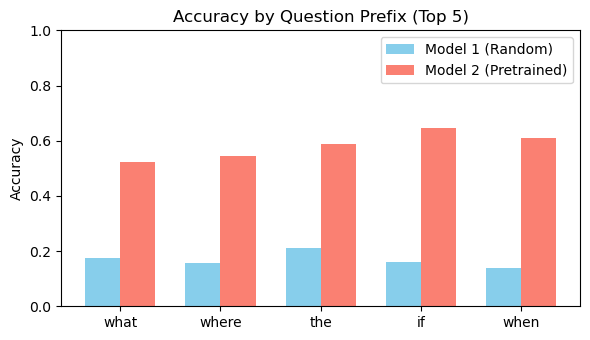

In [38]:
def get_prefix_accuracy(results, top_n=5):
    stats = defaultdict(lambda: {"correct": 0, "total": 0})
    for i in range(len(results["labels"])):
        q = results["samples"][i]["question"]
        prefix = q.strip().split()[0].lower()
        correct = results["preds"][i] == results["labels"][i]
        stats[prefix]["total"] += 1
        if correct:
            stats[prefix]["correct"] += 1

    sorted_items = sorted(stats.items(), key=lambda x: x[1]["total"], reverse=True)[:top_n]
    prefixes = [k for k, _ in sorted_items]
    accs = [stats[p]["correct"] / stats[p]["total"] for p in prefixes]
    return prefixes, accs

prefixes1, accs1 = get_prefix_accuracy(results_model1)
prefixes2, accs2 = get_prefix_accuracy(results_model2)

x = np.arange(len(prefixes1))
width = 0.35

plt.figure(figsize=(6, 3.5))
plt.bar(x - width/2, accs1, width, label="Model 1 (Random)", color="skyblue")
plt.bar(x + width/2, accs2, width, label="Model 2 (Pretrained)", color="salmon")

plt.xticks(x, prefixes1)
plt.ylabel("Accuracy")
plt.title("Accuracy by Question Prefix (Top 5)")
plt.ylim(0, 1)
plt.legend()
plt.tight_layout()
plt.show()

(**ChatGPT** was used to print the two plots side by side)

In [37]:
def compare_question_length_distributions(results1, name1, results2, name2):
    def extract_lengths(results):
        lengths = [len(q["question"].split()) for q in results["samples"]]
        correct = [p == l for p, l in zip(results["preds"], results["labels"])]
        correct_lengths = [l for l, c in zip(lengths, correct) if c]
        wrong_lengths = [l for l, c in zip(lengths, correct) if not c]
        return correct_lengths, wrong_lengths

    correct1, wrong1 = extract_lengths(results1)
    correct2, wrong2 = extract_lengths(results2)

    fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

    axes[0].hist([correct1, wrong1], bins=10, label=["Correct", "Wrong"], color=["green", "red"], alpha=0.7)
    axes[0].set_title(f"{name1}")
    axes[0].set_xlabel("Question Length (words)")
    axes[0].set_ylabel("Count")
    axes[0].legend()

    axes[1].hist([correct2, wrong2], bins=10, label=["Correct", "Wrong"], color=["green", "red"], alpha=0.7)
    axes[1].set_title(f"{name2}")
    axes[1].set_xlabel("Question Length (words)")
    axes[1].legend()

    plt.suptitle("Question Length Distribution by Correctness")
    plt.tight_layout()
    plt.show()

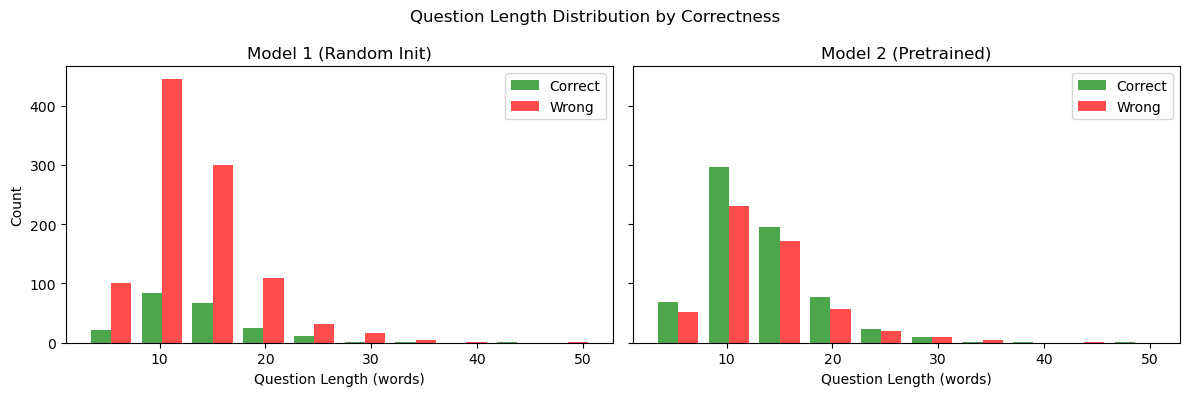

In [38]:
compare_question_length_distributions(
    results_model1, "Model 1 (Random Init)",
    results_model2, "Model 2 (Pretrained)"
)

In [39]:
def accuracy_by_question_length_detailed(results):
    lengths = [len(q.split()) for q in [ex["question"] for ex in results["samples"]]]
    correct = [pred == label for pred, label in zip(results["preds"], results["labels"])]
    bins = [0, 8, 12, 16, 20, 100]
    acc_per_bin = {}

    for i in range(len(lengths)):
        for j in range(len(bins) - 1):
            if bins[j] < lengths[i] <= bins[j+1]:
                key = f"{bins[j]+1}-{bins[j+1]}"
                acc_per_bin.setdefault(key, []).append(correct[i])
                break

    for bin_label, values in acc_per_bin.items():
        acc = sum(values) / len(values)
        print(f"{bin_label} words: {acc:.2f} ({len(values)} samples)")

In [40]:
accuracy_by_question_length_detailed(results_model1)
accuracy_by_question_length_detailed(results_model2)

17-20 words: 0.21 (138 samples)
1-8 words: 0.18 (203 samples)
9-12 words: 0.15 (446 samples)
13-16 words: 0.18 (320 samples)
21-100 words: 0.18 (114 samples)
17-20 words: 0.51 (138 samples)
1-8 words: 0.59 (203 samples)
9-12 words: 0.55 (446 samples)
13-16 words: 0.53 (320 samples)
21-100 words: 0.58 (114 samples)


In [43]:
def plot_wrong_answer_distributions_transfomers(results1, results2, name1="Model 1", name2="Model 2"):
    preds1, labels1 = results1["preds"], results1["labels"]
    preds2, labels2 = results2["preds"], results2["labels"]

    wrong_preds1 = [p for p, l in zip(preds1, labels1) if p != l]
    wrong_preds2 = [p for p, l in zip(preds2, labels2) if p != l]

    counts1 = [wrong_preds1.count(i) for i in range(5)]
    counts2 = [wrong_preds2.count(i) for i in range(5)]

    labels = ["A", "B", "C", "D", "E"]
    x = np.arange(len(labels))
    width = 0.35

    plt.figure(figsize=(8, 4))
    plt.bar(x - width/2, counts1, width, label=name1, color="skyblue")
    plt.bar(x + width/2, counts2, width, label=name2, color="salmon")

    plt.xticks(x, labels)
    plt.xlabel("Predicted Answer (Wrong Only)")
    plt.ylabel("Count")
    plt.title("Wrong Predictions per Answer Option")
    plt.legend()
    plt.tight_layout()
    plt.show()

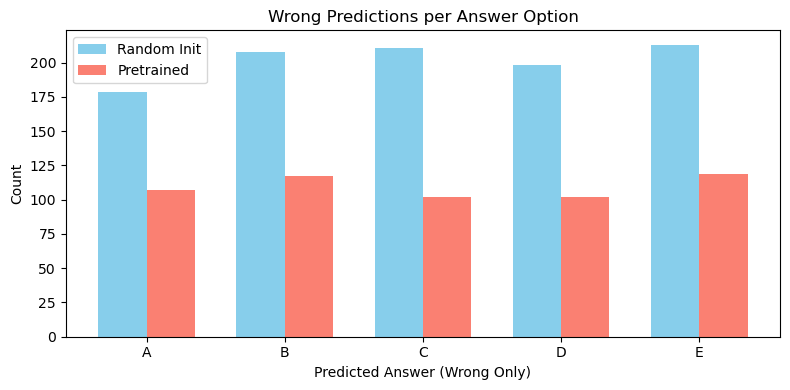

In [44]:
plot_wrong_answer_distributions_transfomers(results_model1, results_model2, "Random Init", "Pretrained")

In [49]:
# examine wrong examples from few-shot llm
for ex in wrong_few[:15]:
    print("Question:", ex["question"])
    for i, choice in enumerate(ex["choices"]):
        print(f"  {chr(65+i)}. {choice}")
    print(f"Correct: {ex['correct']} | Predicted: {ex['predicted']}")
    print("Model Output:", ex["output"])
    print("-" * 50)

Question: What do people typically do while playing guitar?
  A. cry
  B. hear sounds
  C. singing
  D. arthritis
  E. making music
Correct: C | Predicted: E
Model Output: E
--------------------------------------------------
Question: Though the thin film seemed fragile, for it's intended purpose it was actually nearly what?
  A. indestructible
  B. durable
  C. undestroyable
  D. indestructible
  E. unbreakable
Correct: D | Predicted: A
Model Output: A
--------------------------------------------------
Question: She was always helping at the senior center, it brought her what?
  A. satisfaction
  B. heart
  C. feel better
  D. pay
  E. happiness
Correct: E | Predicted: A
Model Output: A
--------------------------------------------------
Question: What is a place that usually does not have an elevator and that sometimes has a telephone book?
  A. at hotel
  B. kitchen
  C. library
  D. telephone booth
  E. house
Correct: E | Predicted: D
Model Output: D
--------------------------------

(**ChatGPT** was used to help find the intersection, I didn't know how I could find these examples)

In [32]:
def show_llm_wins(wrong_model1, wrong_model2, correct_questions, max_display=10):
    shared_wrong = set([ex['question'] for ex in wrong_model1]) & set([ex['question'] for ex in wrong_model2])
    
    wins = shared_wrong.intersection([ex["question"] for ex in correct_questions])

    print(f"\nLLM answered correctly while both BERT models failed ({len(wins)} cases):\n")

    for q in list(wins)[:max_display]:
        match = next((ex for ex in correct_questions if ex["question"] == q), None)
        if match:
            print("Question:", match["question"])
            for i, c in enumerate(match["choices"]["text"]):
                print(f"  {chr(65+i)}. {c}")
            print("-" * 50)

In [33]:
show_llm_wins(
    wrong_model1=wrong_model1,
    wrong_model2=wrong_model2,
    correct_questions=[ex for ex in test if ex['question'] not in [w['question'] for w in wrong_few]]
)


LLM answered correctly while both BERT models failed (379 cases):

Question: Where would you find a monkey in the wild?
  A. zoo
  B. barrel
  C. research laboratory
  D. captivity
  E. thailand
--------------------------------------------------
Question: If you're seeking a connection for your laptop, what are you trying to hook up with?
  A. computer network
  B. electrical circuit
  C. lineage
  D. company
  E. wall
--------------------------------------------------
Question: What is someone who isn't clever, bright, or competent called?
  A. clumsy
  B. ineffectual
  C. dull
  D. clumsy
  E. stupid
--------------------------------------------------
Question: The potato might be the official vegetable of what?
  A. vegans
  B. kitchen cupboard
  C. restaurants
  D. chicken
  E. maryland
--------------------------------------------------
Question: Stark was just having fun, and he wasn't hurting anyone.  What might have he been doing?
  A. painting his nails
  B. playing marbles
  C

### Results
The confusion matrices show that the pretrained model made more correct predictions across all five answer classes. When looking at the first word (prefix) of each question, the pretrained model was more accurate across the five most common prefixes. This pattern held for all top prefixes like “what”, “where”, and “if”. The randomly initialized model performed worse on each of them. For the prefix “what”, the pretrained model achieved 0.52 accuracy, compared to 0.18 for the random model. I also grouped questions by length and looked at how each model performed. The pretrained model had relatively stable accuracy across all length ranges. In contrast, the randomly initialized model struggled across the board, especially with longer questions. A breakdown of wrong predictions by answer option showed that the randomly initialized model made more errors overall and distributed them fairly evenly across A–E. The pretrained model made fewer wrong guesses, with no particular answer choice standing out.

Across 10 manually inspected wrong predictions per model, the randomly initialized model more often chose unrelated or implausible answers. In contrast, the pretrained model's mistakes were generally closer to the correct answer. In cases of disagreement between the models, both were often wrong, but their errors differed.

FLAN-T5-XL (few-shot) correctly answered 379 examples that both BERT models failed. Wrong predictions by the LLM were often close in meaning but incorrect in detail, such as choosing “shower stall” instead of “bathtub” for the question "Where would you find a single shower curtain being used?".

## Interpretation
Before starting this project, I expected pretraining to make a big difference. In Project 1, simpler models (GRUs and MLP) only got around 25% accuracy, so I figured that a pretrained Transformer would do a lot better and it did. Pretrained BERT reached 55.1% on the test set, while the randomly initialized BERT barely got above chance level.

What I didn’t expect was that the MLP and GRU from Project 1, even though they’re way simpler, still did better than Random BERT. That showed me that having a deep model doesn’t help at all if it starts from scratch with no language understanding. I think the random BERT model ended up learning unstable or misleading patterns from the data, which may have made it even worse than random guessing. So I think pretraining it’s what actually gives the model the ability to understand and generalize.

What also surprised me was how well FLAN-T5-XL performed. Even without any fine-tuning it hit almost 89% accuracy. I think this has a lot to do with its scale and the fact that it was instruction-tuned on a wide range of tasks. It likely saw tasks similar to CommonsenseQA during training, so it could generalize without needing new labeled data. Few-shot prompting gave a small boost, but zero-shot was already super strong.

One possible reason why pretrained BERT handled longer and more complex questions better might be that it had already seen lots of different sentence types during pretraining. That probably helped it not get confused by unusual phrasing or longer input.

Overall, this project made me realize how much model performance depends on what the model has seen—not just how it’s built. It also got me thinking more about when it makes sense to fine-tune a model versus when prompting might actually be the better option especially when you don’t have a lot of labeled data.

So my main take-aways are:
- Pretraining is essential for learning generalizable patterns
- Fine-tuning helps but has limitations
- Instruction-tuned LLMs offer strong out-of-the-box performance, even without access to labeled task data
- Prompting, particularly few-shot, can be a solid alternative to traditional model training

## Tools used

- Hugging Face Transformers & Datasets (for models + data loading)
- Weights & Biases (experiment tracking and hyperparameter sweeps)
- ChatGPT for grammar/spelling mistakes (reformulated most sentences of section descriptions)